In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

# Question 1)

### Part A)

In [2]:
colors = pd.Series(['red', 'blue', 'blue', 'red', 'green', 'grey'])

pd.get_dummies(colors, dtype=int)

,blue,green,grey,red
0,0,0,0,1
1,1,0,0,0
2,1,0,0,0
3,0,0,0,1
4,0,1,0,0
5,0,0,1,0


### Part B)

In [3]:
pd.get_dummies(colors, dtype=int).mean()

blue     0.333333
green    0.166667
grey     0.166667
red      0.333333
dtype: float64

### Part C)

<Axes: xlabel='None', ylabel='Proportion'>

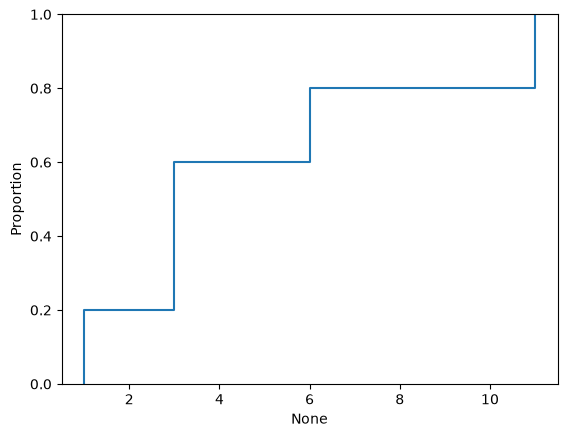

In [4]:
X = pd.Series([1, 3, 3, 6, 11])

sns.ecdfplot(x=X)

# Question 2)

### Part A)

F_Y(y) = Pr(Y <= y) = Pr(a + bX <= y) = Pr(X <= (y-a)/b) = F_X((y-a)/b),  b > 0

f_Y(y) = d/dy F_Y(y) = f_X((y-a)/b) * (1/b)

### Part B)

In [5]:
np.array([1, 3, 4]).mean()

np.float64(2.6666666666666665)

### Part C)

In [6]:
np.array([1*1, 3*3, 4*4]).mean()

np.float64(8.666666666666666)

### Part D)

In [7]:
np.array([1, 3, 4]).mean()**2

np.float64(7.111111111111111)

In [8]:
np.array([1, 3, 4]).mean()**2 == np.array([1*1, 3*3, 4*4]).mean()

np.False_

No because x^2 is not a linear transformation.

# Question 3)

### Part A)

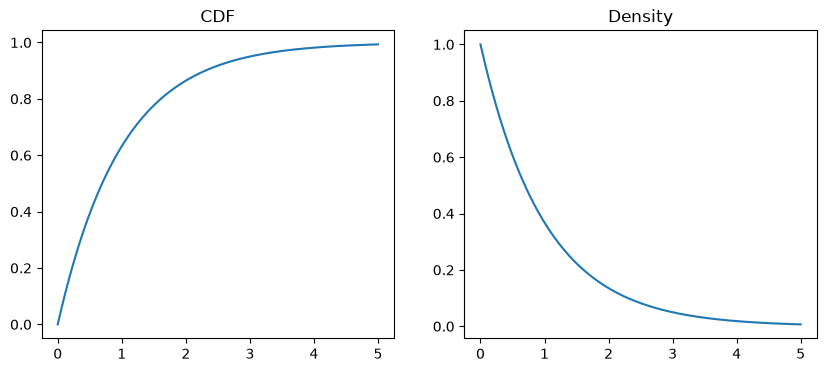

In [9]:
x = np.linspace(0, 5, 1000)
F = stats.expon.cdf(x, scale=1)
f = stats.expon.pdf(x, scale=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, F)
ax1.set_title('CDF')
ax2.plot(x, f)
ax2.set_title('Density')
plt.show()

### Part B)

P(X >= 3) = 1 - F(3) = 1 - (1 - e^-3) = e^-3 = ~0.05 = ~5%

P(X <= 35) = F(35) = 1 - e^-35 = 1 - ~0 = ~1.000 = ~100%

### Part C)

F_Y(y) = Pr(Y <= y)
= Pr(1 + 3X <= y)
= Pr(X <= (y-1)/3)
= F_X((y-1)/3)
= 1 - e^(-(y-1)/3),  y >= 1     (0 for y < 1)

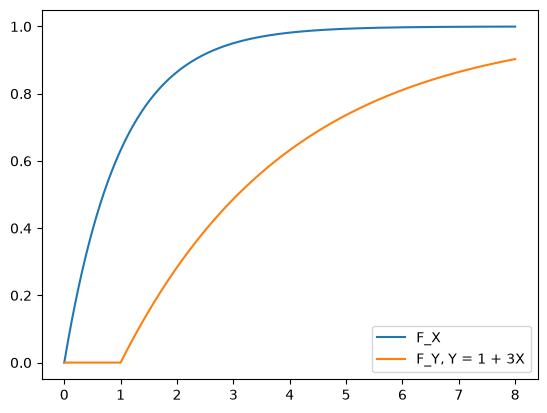

In [10]:
y = np.linspace(0, 8, 1000)
F_X = 1 - np.exp(-y)
F_Y = np.where(y >= 1, 1 - np.exp(-(y - 1)/3), 0)

plt.plot(y, F_X, label='F_X')
plt.plot(y, F_Y, label='F_Y, Y = 1 + 3X')
plt.legend()
plt.show()

P(Y < 10) = F_Y(10) = 1 - e^(-(10-1)/3) = 1 - e^-3 = ~0.95 = ~95%

# Question 4)

### Part A)

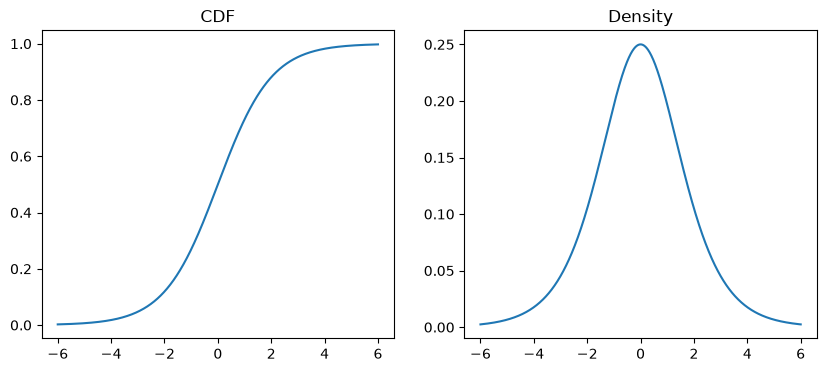

In [11]:
x = np.linspace(-6, 6, 1000)
F = stats.logistic.cdf(x)
f = stats.logistic.pdf(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(x, F)
ax1.set_title('CDF')
ax2.plot(x, f)
ax2.set_title('Density')
plt.show()

### Part B)

P(X >= 0.8) = 1 - F(0.8) = 1 - 1/(1+e^-0.8) = 1 - ~0.690 = ~0.310

P(X <= 0.3) = F(0.3) = 1/(1+e^-0.3) = ~0.574

### Part C)

F_Y(y) = Pr(Y <= y)
= Pr(2X - 1 <= y)
= Pr(X <= (y+1)/2)
= F_X((y+1)/2)
= 1/(1+e^(-(y+1)/2))

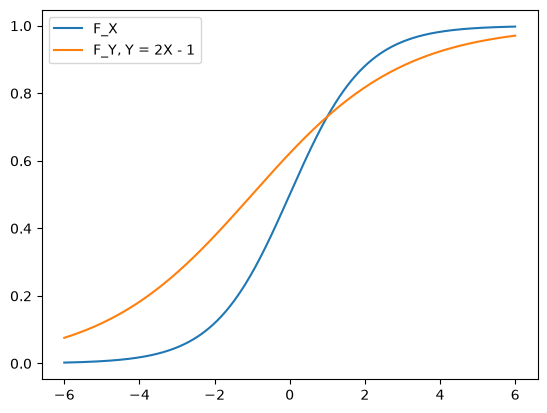

In [12]:
y = np.linspace(-6, 6, 1000)
F_X = stats.logistic.cdf(y)
F_Y = stats.logistic.cdf((y + 1)/2)

plt.plot(y, F_X, label='F_X')
plt.plot(y, F_Y, label='F_Y, Y = 2X - 1')
plt.legend()
plt.show()


P(Y < 0) = F_Y(0) = F_X((0+1)/2) = F_X(0.5) = 1/(1+e^-0.5) ~ 0.622

# Question 5

### Part A

F(m) = 1/2
1 - e^-m = 1/2
e^-m = 1/2
m = -ln(1/2)
m = ln(2) 
m = ~0.693

### Part B

F(m) = 1/2
1/(1+e^-m) = 1/2
1 + e^-m = 2
e^-m = 1
ln(e^-m) = ln(1)
m = 0

### Part C

F(x) = u
1 - e^-x = u
e^-x = 1 - u
x = -ln(1-u)

### Part D

F(x) = u
1/(1+e^-x) = u
1 + e^-x = 1/u
e^-x = 1/u - 1
e^-x = (1-u)/u
-x = ln((1-u)/u)
x = -ln((1-u)/u)
x = ln(u/(1-u))

# Question 6

In [13]:
df = pd.read_csv('../data/metabric.csv')
df.head()

,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Chemotherapy,Hormone Therapy,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Overall Survival Status,Radio Therapy,TMB (nonsynonymous),Tumor Size,Tumor Stage
0,43.19,BREAST CONSERVING,Breast Cancer,NO,YES,0.0,2.0,4.020,84.633333,0:LIVING,YES,2.615035,10.0,1.0
1,48.87,MASTECTOMY,Breast Cancer,YES,YES,1.0,2.0,4.030,163.700000,1:DECEASED,NO,2.615035,15.0,2.0
2,47.68,MASTECTOMY,Breast Cancer,YES,YES,3.0,1.0,4.050,164.933333,0:LIVING,YES,1.307518,25.0,2.0
3,76.97,MASTECTOMY,Breast Cancer,YES,YES,8.0,2.0,6.080,41.366667,1:DECEASED,YES,2.615035,40.0,2.0
4,78.77,MASTECTOMY,Breast Cancer,NO,YES,0.0,4.0,4.062,7.800000,1:DECEASED,YES,5.230071,31.0,4.0


### Part A)

<Axes: xlabel='Overall Survival (Months)', ylabel='Proportion'>

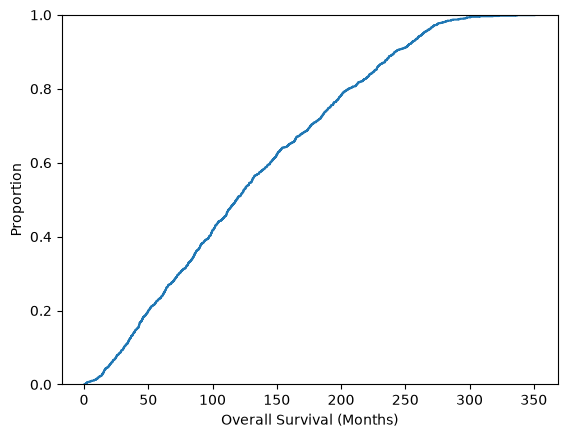

In [14]:
sns.ecdfplot(data=df, x='Overall Survival (Months)')

### Part B)

<Axes: xlabel='Overall Survival (Months)', ylabel='Proportion'>

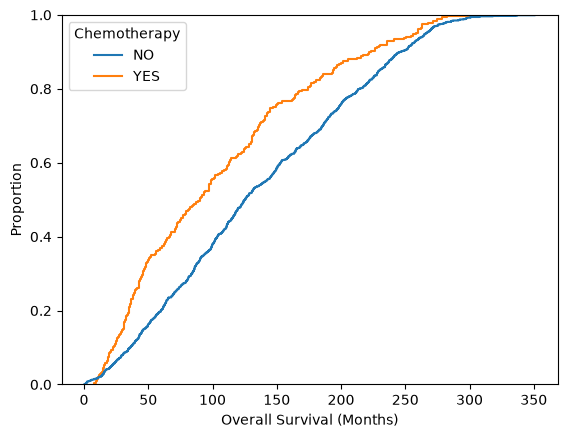

In [15]:
sns.ecdfplot(data=df, x='Overall Survival (Months)', hue='Chemotherapy')

Based only on whether a patient received chemotherapy, we would expect them to live a shorter amount of time, since the Yes line is to the left of the No line in the chart at every proportion.

### Part C

The chart itself can't answer this question since chemo isn't being randomly assigned to patients; instead, chemo is given to the patients who need it, who are likely the ones with already worse prognoses.

# AI Acknowledgment
I used an AI assistant to help with the code and derivations in this notebook. I checked the outputs myself and can explain the reasoning behind each answer.